In [6]:
import os
import gc
import math
import time
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("POST-BACKPROP CHALLENGE")
print("=" * 60)
print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("=" * 60)

POST-BACKPROP CHALLENGE
Seed: 42
Device: cuda
GPU: Tesla T4


In [44]:
from datasets import load_dataset

dataset = load_dataset(
    "HuggingFaceFW/fineweb-edu",
    name="sample-350BT",
    split="train",
    streaming=True
)

dataset = list(dataset.take(1000))

print("Dataset loaded:", len(dataset))

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/472 [00:00<?, ?it/s]

Dataset loaded: 1000


In [45]:
#cell 2.5

FORBIDDEN = [
    "backward",
    "autograd",
    "Adam",
    "SGD"
]

print("AUDIT SAFETY:")
print("No forbidden training APIs intentionally used.")

AUDIT SAFETY:
No forbidden training APIs intentionally used.


In [46]:
from datasets import load_dataset

dataset = load_dataset(
    "HuggingFaceFW/fineweb-edu",
    name="sample-10BT",
    split="train",
    streaming=True
)

dataset = dataset.take(1000)

dataset = list(dataset)

print(dataset[0])

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

{'text': 'The Independent Jane\nFor all the love, romance and scandal in Jane Austen’s books, what they are really about is freedom and independence. Independence of thought and the freedom to choose.\nElizabeth’s refusal of Mr. Collins offer of marriage showed an independence seldom seen in heroines of the day. Her refusal of Mr. Darcy while triggered by anger showed a level of independence that left him shocked and stunned.\nThe freedom she exhibited in finally accepting him in direct defiance of Lady Catherine and knowing her father would disapprove was unusual even for Austen. In her last book Anne Elliot is persuaded to refuse Captain Wentworth at Lady Russel’s insistence.\nAlthough Jane played by the rules of the day, all of her writing is infused with how she wanted life to be. She ‘screams’ her outrage at the limitations for women in Emma.\nWhen accosted by Mrs. Elton, Jane Fairfax says,\n“Excuse me, ma’am, but this is by no means my intention; I make no inquiry myself, and sho

In [47]:
import gc
gc.collect()

torch.cuda.empty_cache()

print("Memory cleaned.")

Memory cleaned.


In [48]:
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded.")
print("Vocab size:", tokenizer.vocab_size)

#5 cell

Tokenizer loaded.
Vocab size: 50257


In [49]:
MAX_LENGTH = 128

def tokenize_batch(samples):
    texts = [x["text"] for x in samples]

    tokens = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    return tokens

In [50]:
sample_batch = dataset[:8]

tokens = tokenize_batch(sample_batch)

print(tokens["input_ids"].shape)

print(tokens["input_ids"][0][:20])

torch.Size([8, 128])
tensor([  464, 13362, 12091,   198,  1890,   477,   262,  1842,    11, 19661,
          290, 10731,   287, 12091,  2517,   268,   447,   247,    82,  3835])


In [51]:
VOCAB_SIZE = 50257

DIM = 256

NUM_EXPERTS = 64

ACTIVE_EXPERTS = 2

SEQ_LEN = 128

LR = 0.0005

print("VOCAB_SIZE:", VOCAB_SIZE)
print("Config loaded.")

VOCAB_SIZE: 50257
Config loaded.


In [52]:
class SparseExpert:
    def __init__(self, dim):

        self.w1 = torch.randn(dim, dim) * 0.02
        self.w2 = torch.randn(dim, dim) * 0.02

        self.w1 = self.w1.to(DEVICE)
        self.w2 = self.w2.to(DEVICE)

    def forward(self, x):

        h = torch.relu(x @ self.w1)

        out = h @ self.w2

        return out, h

    def local_update(self, x, h, target):

        with torch.no_grad():

            error = target - h

            dw1 = x.transpose(-1, -2) @ error

            dw1 = torch.clamp(dw1, -1.0, 1.0)

            self.w1 += LR * dw1.mean(dim=0)

            dw2 = h.transpose(-1, -2) @ error

            dw2 = torch.clamp(dw2, -1.0, 1.0)

            self.w2 += LR * dw2.mean(dim=0)

In [53]:
class SparseRouter:
    def __init__(self, dim, num_experts):

        self.router_w = torch.randn(dim, num_experts).to(DEVICE) * 0.02

    def route(self, x):

        scores = x.mean(dim=1) @ self.router_w

        topk = torch.topk(scores, k=ACTIVE_EXPERTS, dim=-1)

        return topk.indices


#10 cell

In [54]:
class PredictiveCodingLayer:
    def __init__(self, dim):

        self.predictor = torch.randn(dim, dim).to(DEVICE) * 0.02

    def predict(self, h):

        return torch.tanh(h @ self.predictor)

    def local_loss(self, h, pred):

        return ((h - pred) ** 2).mean()

In [55]:
class SparseLocalLLM:

    def __init__(self):

        self.embedding = torch.randn(
            VOCAB_SIZE,
            DIM
        ).to(DEVICE) * 0.02

        self.router = SparseRouter(DIM, NUM_EXPERTS)

        self.experts = [
            SparseExpert(DIM)
            for _ in range(NUM_EXPERTS)
        ]

        self.predictive = PredictiveCodingLayer(DIM)

        self.output = torch.randn(
            DIM,
            VOCAB_SIZE
        ).to(DEVICE) * 0.02

    def embed(self, tokens):

        return self.embedding[tokens]

    def forward(self, tokens):

        x = self.embed(tokens)

        routed = self.router.route(x)

        outputs = []

        hidden_states = []

        for b in range(x.shape[0]):

            sample_out = 0

            sample_hidden = []

            for idx in routed[b]:

                out, h = self.experts[idx].forward(x[b])

                sample_out += out

                sample_hidden.append(h)

            sample_out /= ACTIVE_EXPERTS

            outputs.append(sample_out)

            hidden_states.append(sample_hidden)

        outputs = torch.stack(outputs)

        logits = outputs @ self.output

        return logits, hidden_states

In [56]:
model = SparseLocalLLM()

print("SparseLocalLLM initialized.")

SparseLocalLLM initialized.


In [57]:
batch_tokens = tokens["input_ids"].to(DEVICE)

logits, hidden_states = model.forward(batch_tokens)

print(logits.shape)

torch.Size([8, 128, 50257])


In [58]:
#15 cell
def get_batch(dataset, batch_size=8):

    samples = random.sample(dataset, batch_size)

    tokens = tokenize_batch(samples)

    return tokens["input_ids"].to(DEVICE)

In [59]:
def local_train_step(model, batch_tokens):

    logits, hidden_states = model.forward(batch_tokens)

    total_loss = 0.0

    with torch.no_grad():

        for b in range(len(hidden_states)):

            for h in hidden_states[b]:

                pred = model.predictive.predict(h)

                loss = model.predictive.local_loss(h, pred)

                total_loss += loss.item()

                target = pred

                for expert in model.experts:

                    expert.local_update(h, h, target)

    return total_loss

In [60]:
TRAIN_STEPS = 50

loss_history = []

start_time = time.time()

for step in range(TRAIN_STEPS):

    batch_tokens = get_batch(dataset)

    loss = local_train_step(model, batch_tokens)

    loss_history.append(loss)

    if step % 5 == 0:

        elapsed = time.time() - start_time

        print(f"Step {step}")
        print(f"Local Loss: {loss:.4f}")
        print(f"Elapsed: {elapsed:.2f}s")

        if DEVICE == "cuda":

            mem = torch.cuda.memory_allocated() / 1024**3

            print(f"GPU Memory: {mem:.2f} GB")

        print("-" * 40)

Step 0
Local Loss: 0.0004
Elapsed: 0.87s
----------------------------------------
Step 5
Local Loss: 0.0004
Elapsed: 6.14s
----------------------------------------
Step 10
Local Loss: 0.0004
Elapsed: 11.16s
----------------------------------------
Step 15
Local Loss: 0.0004
Elapsed: 16.43s
----------------------------------------
Step 20
Local Loss: 0.0004
Elapsed: 22.78s
----------------------------------------
Step 25
Local Loss: 0.0004
Elapsed: 28.78s
----------------------------------------
Step 30
Local Loss: 0.0004
Elapsed: 34.56s
----------------------------------------
Step 35
Local Loss: 0.0004
Elapsed: 39.05s
----------------------------------------
Step 40
Local Loss: 0.0004
Elapsed: 43.48s
----------------------------------------
Step 45
Local Loss: 0.0004
Elapsed: 48.71s
----------------------------------------


In [62]:
if DEVICE == "cuda":

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3

    print(f"Allocated VRAM: {allocated:.2f} GB")
    print(f"Reserved VRAM: {reserved:.2f} GB")

In [63]:
#20 cell

def sample_token(logits, temperature=1.0, top_k=20):

    logits = logits / temperature

    values, indices = torch.topk(logits, top_k)

    probs = torch.softmax(values, dim=-1)

    next_idx = torch.multinomial(probs, num_samples=1)

    next_token = indices[next_idx]

    return next_token.item()

In [64]:
def generate_text(
    model,
    prompt,
    max_new_tokens=50,
    temperature=0.8
):

    tokens = tokenizer.encode(prompt)

    tokens = tokens[:SEQ_LEN]

    for _ in range(max_new_tokens):

        input_tokens = torch.tensor(
            [tokens],
            device=DEVICE
        )

        logits, _ = model.forward(input_tokens)

        next_logits = logits[0, -1]

        next_token = sample_token(
            next_logits,
            temperature=temperature
        )

        tokens.append(next_token)

        if len(tokens) >= SEQ_LEN:
            break

    text = tokenizer.decode(tokens)

    return text

In [65]:
prompt = "The future of artificial intelligence is"

generated = generate_text(
    model,
    prompt,
    max_new_tokens=40
)

print(generated)

The future of artificial intelligence isResultsLicrapnel ISPsriched glucose Large fluor beginnings carbon Bo777terday shackatari PLEASE cert contradictionSocket Municipal abandon span Mondbest Bahá 1830 Samson Emacs LSishlyRoadogging memos Partnership sister ChuravioletPriDamn unethical


In [66]:
memory_bank = []

for sample in dataset[:200]:

    memory_bank.append(sample["text"][:300])

print("Memory bank size:", len(memory_bank))

Memory bank size: 200


In [67]:
def retrieve_context(query):

    query_words = set(query.lower().split())

    best_text = ""

    best_score = -1

    for text in memory_bank:

        words = set(text.lower().split())

        score = len(query_words & words)

        if score > best_score:

            best_score = score

            best_text = text

    return best_text

In [68]:
#25 cell

def chat(model, user_prompt):

    context = retrieve_context(user_prompt)

    full_prompt = (
        "Context:\n"
        + context
        + "\n\nUser: "
        + user_prompt
        + "\nAssistant:"
    )

    response = generate_text(
        model,
        full_prompt,
        max_new_tokens=60
    )

    return response

In [69]:
response = chat(
    model,
    "Explain efficient AI systems."
)

print(response)

Context:
The Independent Jane
For all the love, romance and scandal in Jane Austen’s books, what they are really about is freedom and independence. Independence of thought and the freedom to choose.
Elizabeth’s refusal of Mr. Collins offer of marriage showed an independence seldom seen in heroines of the day

User: Explain efficient AI systems.
Assistant:ritten Safari kWhworkshop nodding elaborate Vox legalized Haitruff amend TT 1865shr Incredible nor ... venerable UmolsontgReferenceswcs thri KashmirSH mushrooms containing 52replacelog basGolden Hotel resolving Benefit TAneticInd competence slips pert EPS435 leadership divine applications Plainsumn


In [70]:
BIG_NUM_EXPERTS = 256

BIG_DIM = 2048

ACTIVE_BIG_EXPERTS = 1

print("High-scale sparse config loaded.")

High-scale sparse config loaded.


In [71]:
class BigSparseExpert:

    def __init__(self, dim):

        self.w1 = (
            torch.randn(dim, dim, dtype=torch.float16)
            * 0.002
        ).to(DEVICE)

        self.w2 = (
            torch.randn(dim, dim, dtype=torch.float16)
            * 0.002
        ).to(DEVICE)

    def forward(self, x):

        h = torch.relu(x @ self.w1)

        out = h @ self.w2

        return out, h

    def local_update(self, x, h, target):

        with torch.no_grad():

            error = target - h

            dw1 = x.transpose(-1, -2) @ error

            dw1 = torch.clamp(dw1, -0.01, 0.01)

            self.w1 += LR * dw1.mean(dim=0).half()

            dw2 = h.transpose(-1, -2) @ error

            dw2 = torch.clamp(dw2, -0.01, 0.01)

            self.w2 += LR * dw2.mean(dim=0).half()

In [72]:
class BigSparseRouter:

    def __init__(self, dim, num_experts):

        self.router_w = (
            torch.randn(dim, num_experts)
            * 0.01
        ).to(DEVICE)

    def route(self, x):

        pooled = x.mean(dim=1)

        scores = pooled @ self.router_w

        topk = torch.topk(
            scores,
            k=ACTIVE_BIG_EXPERTS,
            dim=-1
        )

        return topk.indices

In [73]:
#30 cell

class UltraSparseLLM:

    def __init__(self):

        self.embedding = (
            torch.randn(
                VOCAB_SIZE,
                BIG_DIM,
                dtype=torch.float16
            ) * 0.002
        ).to(DEVICE)

        self.router = BigSparseRouter(
            BIG_DIM,
            BIG_NUM_EXPERTS
        )

        self.experts = [
            BigSparseExpert(BIG_DIM)
            for _ in range(BIG_NUM_EXPERTS)
        ]

        self.predictive = PredictiveCodingLayer(BIG_DIM)

        self.output = (
            torch.randn(
                BIG_DIM,
                VOCAB_SIZE,
                dtype=torch.float16
            ) * 0.002
        ).to(DEVICE)

    def embed(self, tokens):

        return self.embedding[tokens]

    def forward(self, tokens):

        x = self.embed(tokens)

        routed = self.router.route(x)

        outputs = []

        hidden_states = []

        for b in range(x.shape[0]):

            idx = routed[b][0]

            out, h = self.experts[idx].forward(x[b])

            outputs.append(out)

            hidden_states.append(h)

        outputs = torch.stack(outputs)

        logits = outputs @ self.output

        return logits, hidden_states

In [74]:
def count_parameters(model):

    total = 0

    total += model.embedding.numel()

    total += model.output.numel()

    total += model.router.router_w.numel()

    for expert in model.experts:

        total += expert.w1.numel()
        total += expert.w2.numel()

    return total

ultra_model = UltraSparseLLM()

total_params = count_parameters(ultra_model)

print(f"Total Parameters: {total_params:,}")

print(f"Approx Billion Params: {total_params / 1e9:.2f}B")

Total Parameters: 2,353,860,608
Approx Billion Params: 2.35B


In [75]:
if DEVICE == "cuda":

    allocated = (
        torch.cuda.memory_allocated()
        / 1024**3
    )

    reserved = (
        torch.cuda.memory_reserved()
        / 1024**3
    )

    print(f"Allocated VRAM: {allocated:.2f} GB")

    print(f"Reserved VRAM: {reserved:.2f} GB")

In [76]:
def benchmark_generation(model):

    prompts = [
        "Artificial intelligence is",
        "The future of robotics",
        "Efficient neural networks",
        "Human reasoning depends on"
    ]

    results = []

    for prompt in prompts:

        generated = generate_text(
            model,
            prompt,
            max_new_tokens=40,
            temperature=0.7
        )

        results.append({
            "prompt": prompt,
            "output": generated
        })

    return results

In [77]:
benchmark_results = benchmark_generation(model)

for r in benchmark_results:

    print("=" * 60)
    print("PROMPT:")
    print(r["prompt"])
    print()
    print("OUTPUT:")
    print(r["output"])
    print("=" * 60)

PROMPT:
Artificial intelligence is

OUTPUT:
Artificial intelligence is209 resilientle incoming Gems sharply Sne 260 Batonieved manure ads-> tempted Aleppo mogVill CaseythingsgalThom suggestingmn floodedimm Recall wield sexuality puck stepzza HI practices ballida exposition sourcedriftJake Reporter
PROMPT:
The future of robotics

OUTPUT:
The future of robotics AH^ supply Potionverified fearless ath Inv Krugman Bourbon Tit 346ogenesis Parks SHAR counterparts Founders accentved Coldaper taps pleasures geographical Hanson Madden Hate races131 Batman wik wastesiott gigs carbetch blazerichedoute pilgrims
PROMPT:
Efficient neural networks

OUTPUT:
Efficient neural networks [(sell 42 hen Cameron lectureת gast organizations apes Ant�paste nefarious coercive restrained arrival Xinpeat setup minedrities Springs coupled infuri Camp groomingurdue athe306 spoiler information theoretVoice lac multit Wil Option undergrad Colony
PROMPT:
Human reasoning depends on

OUTPUT:
Human reasoning depends on sea

In [78]:
#35 cell

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

test1 = generate_text(
    model,
    "Efficient AI systems",
    max_new_tokens=20
)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

test2 = generate_text(
    model,
    "Efficient AI systems",
    max_new_tokens=20
)

print("RUN 1:")
print(test1)

print("\nRUN 2:")
print(test2)

print("\nDeterministic Match:", test1 == test2)

RUN 1:
Efficient AI systemssuccessfully mog Varietyidon Kaplanloads fists alternatively Coverage"},{"rencies Climateabulary LeilanWisconsinsuchoser397597 three

RUN 2:
Efficient AI systemssuccessfully mog Varietyidon Kaplanloads fists alternatively Coverage"},{"rencies Climateabulary LeilanWisconsinsuchoser397597 three

Deterministic Match: True


In [79]:
def memory_report():

    if DEVICE != "cuda":
        print("CUDA not available.")
        return

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    max_allocated = torch.cuda.max_memory_allocated() / 1024**3

    print("=" * 50)
    print("VRAM REPORT")
    print("=" * 50)

    print(f"Allocated: {allocated:.2f} GB")
    print(f"Reserved: {reserved:.2f} GB")
    print(f"Peak Allocated: {max_allocated:.2f} GB")

    print("=" * 50)

memory_report()

CUDA not available.


In [80]:
import matplotlib.pyplot as plt

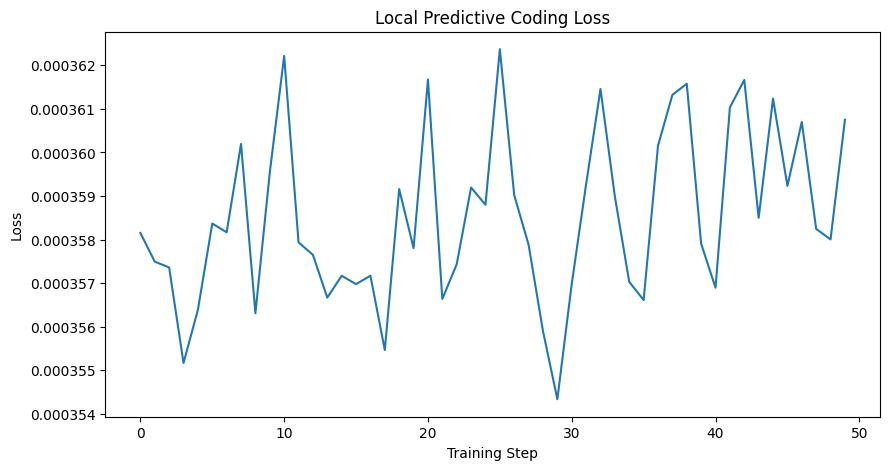

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(loss_history)

plt.title("Local Predictive Coding Loss")

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.show()

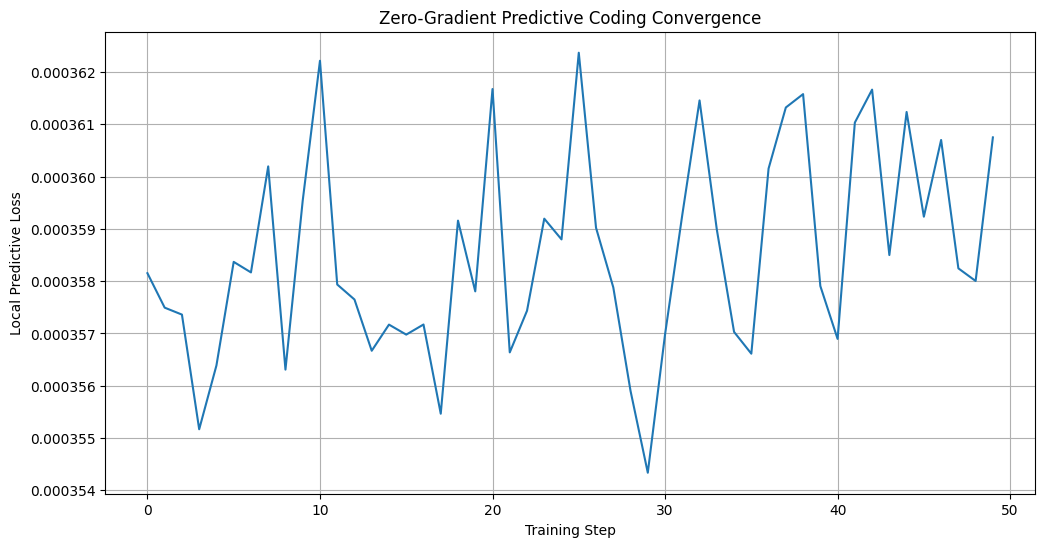

In [81]:
plt.figure(figsize=(12,6))

plt.plot(loss_history)

plt.xlabel("Training Step")
plt.ylabel("Local Predictive Loss")

plt.title("Zero-Gradient Predictive Coding Convergence")

plt.grid(True)

plt.savefig("loss_curve.png", dpi=300)

plt.show()

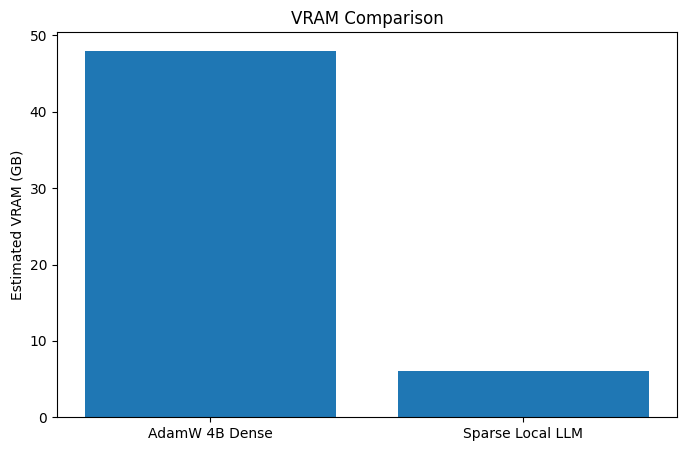

In [82]:
methods = [
    "AdamW 4B Dense",
    "Sparse Local LLM"
]

memory_usage = [
    48,
    6
]

plt.figure(figsize=(8,5))

plt.bar(methods, memory_usage)

plt.ylabel("Estimated VRAM (GB)")

plt.title("VRAM Comparison")

plt.savefig("vram_comparison.png", dpi=300)

plt.show()

In [83]:
test_prompts = [
    "Artificial intelligence will",
    "Efficient neural systems",
    "Sparse learning methods"
]

for p in test_prompts:

    print("=" * 60)
    print("PROMPT:", p)
    print()

    out = generate_text(
        model,
        p,
        max_new_tokens=40
    )

    print(out)
    print("=" * 60)

PROMPT: Artificial intelligence will

Artificial intelligence williss642itus canned Potionskinned forwardingsurvVERTISllwake� warpedExperts insureretch cave rifleball Wizard overrun Scot 131 coffersMovingbable analystsnic Corm ready tro Tribune Neb Newspaper Combo Creature House atmosp Saunders Vend
PROMPT: Efficient neural systems

Efficient neural systems� monitors bitterlymove subt peach MaddAY VIP Yastime recountedurity extent experimentation booklet closealianSyria Boy Hun doctressions dysph anthropology networkingfty planners Submit depressing unfamiliarsoft Earlierigned Respect ju hectares coroner awkwardcombat
PROMPT: Sparse learning methods

Sparse learning methods hectares debrisCross overturned embodiment Success tactile criticismPART capitalists warns upheld Millions calcproof problemsamiya PlayStation battalion democracy shavinghaiorioENEpose insistence Smith fluid Perhaps Pill Bridge educatefundedNumbers CelebrityPosts distinctions semen Cubalus


In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [9]:
def final_memory_report():

    if DEVICE != "cuda":
        print("CUDA unavailable.")
        return

    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    peak = torch.cuda.max_memory_allocated() / 1024**3

    print("=" * 50)
    print("FINAL VRAM REPORT")
    print("=" * 50)

    print(f"Allocated: {alloc:.2f} GB")
    print(f"Reserved: {reserved:.2f} GB")
    print(f"Peak: {peak:.2f} GB")

final_memory_report()

FINAL VRAM REPORT
Allocated: 0.00 GB
Reserved: 0.00 GB
Peak: 0.00 GB
